In [1]:
import numpy as np
import matplotlib.pyplot as plt

x_min = float(input("Enter x minimum: "))
x_max = float(input("Enter x maximum: "))
points = int(input("Enter number of points: "))

x = np.linspace(x_min, x_max, points)
print(x)
y = x**2
print(y)

[-20.         -19.95995996 -19.91991992 -19.87987988 -19.83983984
 -19.7997998  -19.75975976 -19.71971972 -19.67967968 -19.63963964
 -19.5995996  -19.55955956 -19.51951952 -19.47947948 -19.43943944
 -19.3993994  -19.35935936 -19.31931932 -19.27927928 -19.23923924
 -19.1991992  -19.15915916 -19.11911912 -19.07907908 -19.03903904
 -18.998999   -18.95895896 -18.91891892 -18.87887888 -18.83883884
 -18.7987988  -18.75875876 -18.71871872 -18.67867868 -18.63863864
 -18.5985986  -18.55855856 -18.51851852 -18.47847848 -18.43843844
 -18.3983984  -18.35835836 -18.31831832 -18.27827828 -18.23823824
 -18.1981982  -18.15815816 -18.11811812 -18.07807808 -18.03803804
 -17.997998   -17.95795796 -17.91791792 -17.87787788 -17.83783784
 -17.7977978  -17.75775776 -17.71771772 -17.67767768 -17.63763764
 -17.5975976  -17.55755756 -17.51751752 -17.47747748 -17.43743744
 -17.3973974  -17.35735736 -17.31731732 -17.27727728 -17.23723724
 -17.1971972  -17.15715716 -17.11711712 -17.07707708 -17.03703704
 -16.99699

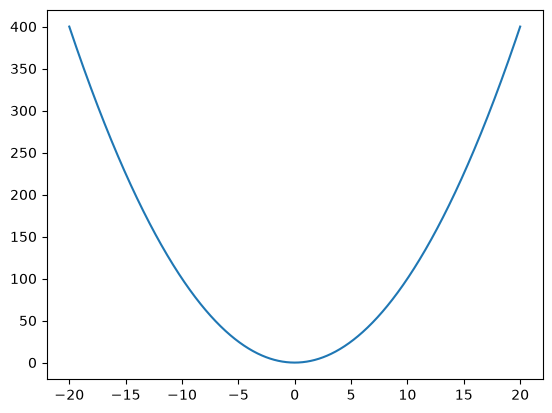

In [2]:
plt.plot(x, y)
plt.show()

In [3]:
import sympy as sp

In [4]:
# equation = "log(x)"
# 
equation = input("Enter an equation in x: ")
x_symbol = sp.symbols("x")

from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application,
)

transformations = standard_transformations + (
    implicit_multiplication_application,
)

try:
    expression = parse_expr(
        equation,
        transformations=transformations
    )

    x_values = np.linspace(-10, 10, 100)

    function = sp.lambdify(x_symbol, expression, "numpy")

    y_values = function(x_values)

    y_values = np.asarray(y_values, dtype=float)

    y_values[~np.isfinite(y_values)] = np.nan

    jumps = np.abs(np.diff(y_values))

    threshold = 100

    y_values[:-1][jumps > threshold] = np.nan
    y_values[1:][jumps > threshold] = np.nan
    valid = np.isfinite(y_values)

    x_values = x_values[valid]
    y_values = y_values[valid]
    
    print(y_values)

except Exception:
    print("Invalid equation. Please try again.")
    exit()






[ 0.54402111  0.36459873  0.17034683 -0.03083368 -0.23076008 -0.42130064
 -0.59470541 -0.74392141 -0.86287948 -0.94674118 -0.99209556 -0.99709789
 -0.96154471 -0.8868821  -0.77614685 -0.63384295 -0.46575841 -0.27872982
 -0.0803643   0.12126992  0.31797166  0.50174037  0.66510151  0.80141062
  0.90512352  0.97202182  0.99938456  0.98609877  0.93270486  0.84137452
  0.7158225   0.56115544  0.38366419  0.19056796 -0.01027934 -0.21070855
 -0.40256749 -0.57805259 -0.73002623 -0.85230712 -0.93992165 -0.98930624
 -0.99845223 -0.96698762 -0.8961922  -0.78894546 -0.64960951 -0.48385164
 -0.2984138  -0.10083842  0.10083842  0.2984138   0.48385164  0.64960951
  0.78894546  0.8961922   0.96698762  0.99845223  0.98930624  0.93992165
  0.85230712  0.73002623  0.57805259  0.40256749  0.21070855  0.01027934
 -0.19056796 -0.38366419 -0.56115544 -0.7158225  -0.84137452 -0.93270486
 -0.98609877 -0.99938456 -0.97202182 -0.90512352 -0.80141062 -0.66510151
 -0.50174037 -0.31797166 -0.12126992  0.0803643   0

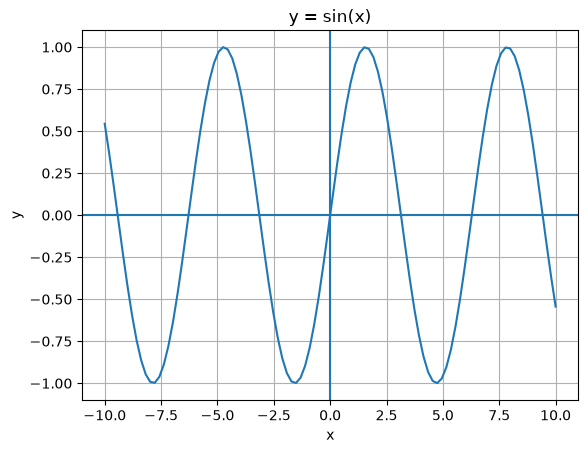

In [5]:
plt.plot(x_values, y_values)

plt.axhline(0)
plt.axvline(0)

plt.grid(True)

plt.xlabel("x")
plt.ylabel("y")

plt.title(f"y = {expression}")

plt.show()